# Label & Annotation Characterization

Statistics on joystick-derived labels across the full dataset.
Labels generated using the same pipeline as the processor (position_peak + dual-axis amplitude voting).

**Analyses:**
1. Global & per-participant class distribution
2. Per-session (placement) class balance
3. Movement region durations
4. Transition matrix & noise-to-movement ratio
5. Joystick kinematics per class

## 1. Setup & Label Generation

In [1]:
import os
import sys
import re
import glob
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project root
PROJECT_ROOT = Path(os.path.abspath('')).parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# ---------- Load configs ----------
CONFIG_PATH = PROJECT_ROOT / 'config' / 'config.yaml'
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

LABEL_CONFIG_PATH = PROJECT_ROOT / config['preprocess']['label_config']
with open(LABEL_CONFIG_PATH) as f:
    label_config = yaml.safe_load(f)

RAW_DATA_PATH = Path(config['global_setting']['paths']['base_data_path']) / 'raw'

# Class definitions from label config
NUM_CLASSES = 5 if label_config['classes']['include_noise'] else 4
CLASS_NAMES = label_config['classes']['names']

# Joystick sampling rate from filter config
JOYSTICK_FS = label_config['filters']['position']['lowpass']['fs']  # 175 Hz

# Position peak parameters
PP_CONFIG = label_config['position_peak']

# Joystick filter config
FILTER_CONFIG = label_config['filters']

# Session → placement mapping (from data collection protocol)
PLACEMENT_MAP = {0: 'table', 1: 'table', 2: 'leg', 3: 'leg', 4: 'side', 5: 'side'}

print(f"Raw data path:    {RAW_DATA_PATH}")
print(f"Classes:          {NUM_CLASSES} — {CLASS_NAMES}")
print(f"Joystick Fs:      {JOYSTICK_FS} Hz")
print(f"Position peak:    {PP_CONFIG}")

Raw data path:    /vol/data/2026_wristus_wiicontroller_sgambato/day002/raw
Classes:          5 — {0: 'Noise', 1: 'Up', 2: 'Down', 3: 'Left', 4: 'Right'}
Joystick Fs:      175 Hz
Position peak:    {'deriv_threshold_percent': 10.0, 'pos_threshold_percent': 5.0, 'peak_window': 3, 'timeout_samples': 500}


In [2]:
# ---------- Experiment index (same as Tier 1) ----------
def build_experiment_index(raw_path):
    """Walk raw data folder, return sorted DataFrame of (participant, session, experiment, path)."""
    rows = []
    for p_dir in sorted(raw_path.glob('P*')):
        if not p_dir.is_dir():
            continue
        p_id = int(re.search(r'P(\d+)', p_dir.name).group(1))
        for s_dir in sorted(p_dir.glob('session*')):
            if not s_dir.is_dir():
                continue
            s_id = int(re.search(r'session(\d+)', s_dir.name).group(1))
            for e_dir in sorted(s_dir.glob('exp*')):
                if not e_dir.is_dir():
                    continue
                e_id = int(re.search(r'exp(\d+)', e_dir.name).group(1))
                rows.append({'participant': p_id, 'session': s_id,
                             'experiment': e_id, 'path': str(e_dir)})
    return pd.DataFrame(rows)

exp_index = build_experiment_index(RAW_DATA_PATH)
exp_index['placement'] = exp_index['session'].map(PLACEMENT_MAP)
print(f"Experiments: {len(exp_index)}")

Experiments: 120


In [3]:
# ---------- Label generation using existing pipeline ----------
from preprocessing.signal_utils import apply_joystick_filters
from preprocessing.label_logic.label_logic import create_5class_position_peak_labels
from tqdm.notebook import tqdm


def load_joystick(exp_path):
    """Load joystick data. Returns [4, pulses] float64 (ch0=unused, ch1=X, ch2=Y, ch3=trigger)."""
    joy_files = sorted(glob.glob(os.path.join(exp_path, '_joystick*.npy')))
    if not joy_files:
        raise FileNotFoundError(f"No joystick file in {exp_path}")
    return np.load(joy_files[0]).T.astype(np.float64)  # [4, pulses]


def generate_labels(joystick):
    """
    Generate 5-class labels from joystick data using the same pipeline as the processor.
    
    Args:
        joystick: [4, pulses] array
    Returns:
        labels, x_filtered, y_filtered, x_velocity, y_velocity
    """
    x_pos = joystick[1, :]
    y_pos = joystick[2, :]

    # Apply same filters as processor
    x_filtered = apply_joystick_filters(x_pos.copy(), FILTER_CONFIG, 'position')
    y_filtered = apply_joystick_filters(y_pos.copy(), FILTER_CONFIG, 'position')
    x_velocity = apply_joystick_filters(np.gradient(x_filtered), FILTER_CONFIG, 'derivative')
    y_velocity = apply_joystick_filters(np.gradient(y_filtered), FILTER_CONFIG, 'derivative')

    labels, thresholds, markers = create_5class_position_peak_labels(
        x_filtered, y_filtered, x_velocity, y_velocity,
        PP_CONFIG['deriv_threshold_percent'], PP_CONFIG['pos_threshold_percent'],
        PP_CONFIG['peak_window'], PP_CONFIG['timeout_samples']
    )
    return labels, x_filtered, y_filtered, x_velocity, y_velocity


# ---------- Generate labels for all experiments ----------
all_labels = {}      # (p, s, e) → labels array
all_kinematics = {}  # (p, s, e) → (x_filt, y_filt, x_vel, y_vel)
label_count_rows = []

for _, row in tqdm(exp_index.iterrows(), total=len(exp_index), desc="Generating labels"):
    joy = load_joystick(row['path'])
    labels, x_f, y_f, x_v, y_v = generate_labels(joy)

    key = (row['participant'], row['session'], row['experiment'])
    all_labels[key] = labels
    all_kinematics[key] = (x_f, y_f, x_v, y_v)

    # Count per class
    unique, counts = np.unique(labels, return_counts=True)
    count_dict = {int(u): int(c) for u, c in zip(unique, counts)}
    total = len(labels)
    label_count_rows.append({
        'participant': row['participant'], 'session': row['session'],
        'experiment': row['experiment'], 'placement': row['placement'],
        'total_samples': total,
        **{f'n_{cls}': count_dict.get(cls, 0) for cls in range(NUM_CLASSES)},
        **{f'pct_{cls}': 100 * count_dict.get(cls, 0) / total for cls in range(NUM_CLASSES)},
    })

df_labels = pd.DataFrame(label_count_rows)
print(f"\nGenerated labels for {len(df_labels)} experiments")
print(f"Total samples: {df_labels['total_samples'].sum():,}")
df_labels.head()

Generating labels:   0%|          | 0/120 [00:00<?, ?it/s]


Generated labels for 120 experiments
Total samples: 745,691


,participant,session,experiment,placement,total_samples,n_0,n_1,n_2,n_3,n_4,pct_0,pct_1,pct_2,pct_3,pct_4
0,0,0,0,table,6172,1903,1153,1041,1017,1058,30.832793,18.681141,16.866494,16.477641,17.141931
1,0,0,1,table,6190,1759,1154,1110,1090,1077,28.416801,18.642973,17.932149,17.609047,17.399031
2,0,0,2,table,6174,1732,1168,1085,1082,1107,28.053126,18.918043,17.573696,17.525105,17.930029
3,0,0,3,table,6147,1567,1158,1206,1034,1182,25.492110,18.838458,19.619327,16.821214,19.228892
4,0,0,4,table,5934,1194,1243,1212,1132,1153,20.121335,20.947085,20.424671,19.076508,19.430401


## 2. Global & Per-Participant Class Distribution

In [4]:
# ---------- Global distribution ----------
global_counts = {cls: int(df_labels[f'n_{cls}'].sum()) for cls in range(NUM_CLASSES)}
global_total = sum(global_counts.values())
global_pcts = {cls: 100 * v / global_total for cls, v in global_counts.items()}

print("Global Class Distribution:")
print(f"{'Class':<12} {'Count':>10} {'Pct':>8}")
print("-" * 32)
for cls in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[cls]:<12} {global_counts[cls]:>10,} {global_pcts[cls]:>7.1f}%")
print(f"{'Total':<12} {global_total:>10,}")

# ---------- Per-participant distribution ----------
part_dist = df_labels.groupby('participant').agg(
    **{f'n_{cls}': (f'n_{cls}', 'sum') for cls in range(NUM_CLASSES)},
    total=('total_samples', 'sum'),
).reset_index()
for cls in range(NUM_CLASSES):
    part_dist[f'pct_{cls}'] = 100 * part_dist[f'n_{cls}'] / part_dist['total']

print("\nPer-Participant Class Distribution (%):")
cols = ['participant'] + [f'pct_{cls}' for cls in range(NUM_CLASSES)]
display_df = part_dist[cols].copy()
display_df.columns = ['Participant'] + [CLASS_NAMES[cls] for cls in range(NUM_CLASSES)]
display_df['Participant'] = [f'P{p}' for p in display_df['Participant']]
print(display_df.round(1).to_string(index=False))

Global Class Distribution:
Class             Count      Pct
--------------------------------
Noise           174,097    23.3%
Up              154,450    20.7%
Down            139,313    18.7%
Left            138,988    18.6%
Right           138,843    18.6%
Total           745,691

Per-Participant Class Distribution (%):
Participant  Noise   Up  Down  Left  Right
         P0   16.4 22.5  20.2  20.2   20.8
         P1   24.1 20.9  18.5  18.6   18.0
         P2   21.5 20.5  19.6  19.0   19.4
         P3   31.3 19.0  16.5  16.8   16.4


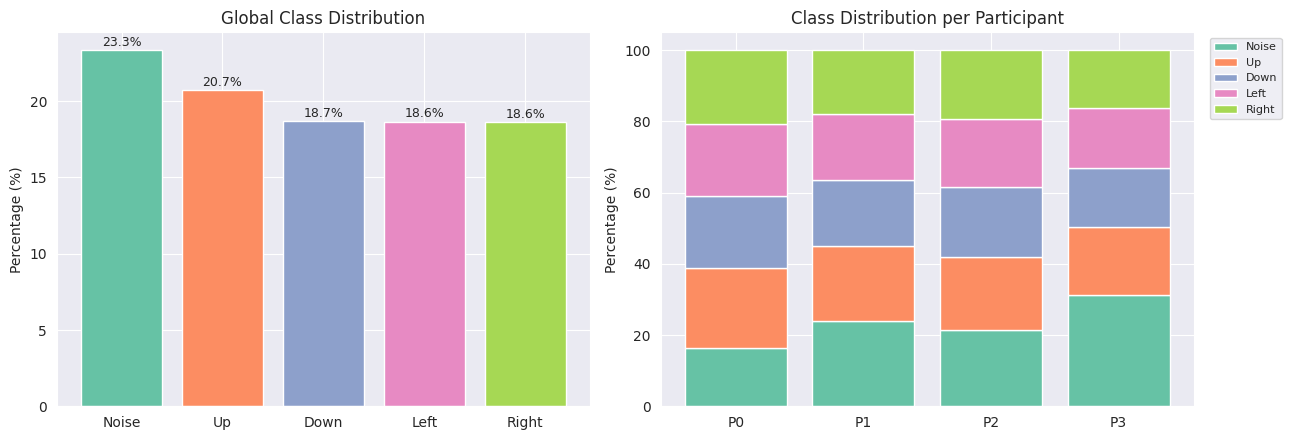

In [5]:
# ---------- Plots ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Global bar chart
colors = sns.color_palette('Set2', NUM_CLASSES)
bars = axes[0].bar([CLASS_NAMES[c] for c in range(NUM_CLASSES)],
                   [global_pcts[c] for c in range(NUM_CLASSES)],
                   color=colors)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Global Class Distribution')
for bar, pct in zip(bars, [global_pcts[c] for c in range(NUM_CLASSES)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', fontsize=9)

# Stacked bar per participant
participants = sorted(df_labels['participant'].unique())
x_pos = np.arange(len(participants))
bottoms = np.zeros(len(participants))
for cls in range(NUM_CLASSES):
    vals = [float(part_dist[part_dist['participant'] == p][f'pct_{cls}'].iloc[0]) for p in participants]
    axes[1].bar(x_pos, vals, bottom=bottoms, label=CLASS_NAMES[cls], color=colors[cls])
    bottoms += vals
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'P{p}' for p in participants])
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Class Distribution per Participant')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Per-Session (Placement) Class Balance

Same movement protocol across all placements — differences here indicate
coupling/threshold sensitivity, not real protocol changes.

```
table = S0, S1  |  leg = S2, S3  |  side = S4, S5
```

In [6]:
from scipy.stats import kruskal

# ---------- Placement × class distribution ----------
placement_dist = df_labels.groupby('placement').agg(
    **{f'n_{cls}': (f'n_{cls}', 'sum') for cls in range(NUM_CLASSES)},
    total=('total_samples', 'sum'),
).reset_index()
for cls in range(NUM_CLASSES):
    placement_dist[f'pct_{cls}'] = 100 * placement_dist[f'n_{cls}'] / placement_dist['total']

print("Class Distribution by Placement (%):")
cols = ['placement'] + [f'pct_{cls}' for cls in range(NUM_CLASSES)]
disp = placement_dist[cols].copy()
disp.columns = ['Placement'] + [CLASS_NAMES[c] for c in range(NUM_CLASSES)]
print(disp.round(1).to_string(index=False))

# ---------- Kruskal-Wallis per class: does placement affect class % ? ----------
print("\nKruskal-Wallis: does placement affect class percentage?")
print(f"{'Class':<10} {'H':>8} {'p-value':>12} {'Sig':>5}")
print("-" * 38)
for cls in range(NUM_CLASSES):
    groups = [grp[f'pct_{cls}'].values for _, grp in df_labels.groupby('placement')]
    h, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{CLASS_NAMES[cls]:<10} {h:>8.2f} {p:>12.3e} {sig:>5}")

Class Distribution by Placement (%):
Placement  Noise   Up  Down  Left  Right
      leg   23.7 20.7  18.5  18.6   18.5
     side   18.5 22.1  19.5  19.8   20.1
    table   27.8 19.3  18.1  17.5   17.3

Kruskal-Wallis: does placement affect class percentage?
Class             H      p-value   Sig
--------------------------------------
Noise         22.12    1.577e-05   ***
Up            22.32    1.426e-05   ***
Down           4.37    1.127e-01      
Left          19.30    6.433e-05   ***
Right         17.27    1.781e-04   ***


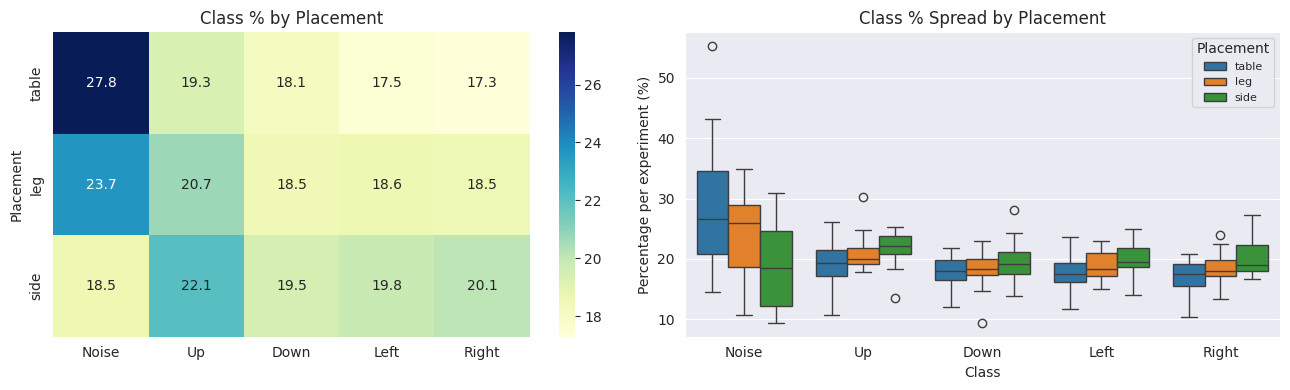

In [7]:
# ---------- Heatmap: placement × class ----------
pivot = placement_dist.set_index('placement')[[f'pct_{c}' for c in range(NUM_CLASSES)]]
pivot.columns = [CLASS_NAMES[c] for c in range(NUM_CLASSES)]
pivot = pivot.loc[['table', 'leg', 'side']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Class % by Placement')
axes[0].set_ylabel('Placement')

# Grouped boxplot: per-experiment class % by placement (shows spread)
df_melt = df_labels.melt(
    id_vars=['participant', 'session', 'experiment', 'placement'],
    value_vars=[f'pct_{c}' for c in range(NUM_CLASSES)],
    var_name='class', value_name='pct'
)
df_melt['class'] = df_melt['class'].map({f'pct_{c}': CLASS_NAMES[c] for c in range(NUM_CLASSES)})

sns.boxplot(data=df_melt, x='class', y='pct', hue='placement',
            hue_order=['table', 'leg', 'side'], ax=axes[1])
axes[1].set_ylabel('Percentage per experiment (%)')
axes[1].set_xlabel('Class')
axes[1].set_title('Class % Spread by Placement')
axes[1].legend(title='Placement', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Movement Region Durations

Contiguous region lengths per class — how long does each movement last?


- Validates tokenization window: if typical regions are shorter, tokens mix classes
- Informs differentiation analysis: short regions may be destroyed by gradient smoothing
- Identifies single-pulse "spike" labels (likely labeling artifacts)

In [8]:
# ---------- Compute contiguous region lengths ----------
def get_region_lengths(labels):
    """Return list of (class, length) for each contiguous region."""
    regions = []
    if len(labels) == 0:
        return regions
    current_cls = labels[0]
    current_len = 1
    for i in range(1, len(labels)):
        if labels[i] == current_cls:
            current_len += 1
        else:
            regions.append((int(current_cls), current_len))
            current_cls = labels[i]
            current_len = 1
    regions.append((int(current_cls), current_len))
    return regions


# Collect across all experiments
region_rows = []
for key, labels in all_labels.items():
    p, s, e = key
    for cls, length in get_region_lengths(labels):
        region_rows.append({
            'participant': p, 'session': s, 'experiment': e,
            'class': cls, 'class_name': CLASS_NAMES[cls],
            'length_pulses': length,
        })

df_regions = pd.DataFrame(region_rows)

# Tokenization window for reference
TOKEN_WINDOW = config['preprocess']['tokenization']['window']  # 25

# ---------- Summary statistics per class ----------
print(f"Total regions: {len(df_regions):,}")
print(f"Tokenization window: {TOKEN_WINDOW} pulses\n")

region_summary = df_regions.groupby('class_name')['length_pulses'].agg(
    count='count', median='median',
    Q25=lambda x: np.percentile(x, 25),
    Q75=lambda x: np.percentile(x, 75),
    min='min', max='max', mean='mean',
).round(1)

# Fraction shorter than tokenization window
for cls_name in CLASS_NAMES.values():
    subset = df_regions[df_regions['class_name'] == cls_name]['length_pulses']
    frac_short = (subset < TOKEN_WINDOW).mean() * 100
    frac_spike = (subset == 1).mean() * 100
    region_summary.loc[cls_name, 'pct_<window'] = round(frac_short, 1)
    region_summary.loc[cls_name, 'pct_spike(=1)'] = round(frac_spike, 1)

print("Region Duration Summary (pulses):")
print(region_summary.to_string())

Total regions: 17,058
Tokenization window: 25 pulses

Region Duration Summary (pulses):
            count  median   Q25   Q75  min  max  mean  pct_<window  pct_spike(=1)
class_name                                                                       
Down         2236    70.0  64.0  76.0    1  104  62.3         12.6            7.2
Left         2214    70.0  62.0  75.0    1  100  62.8          8.3            1.5
Noise        7763    21.0  12.0  29.0    1  498  22.4         61.8            0.5
Right        2277    67.0  60.0  73.0    1  101  61.0          8.4            1.8
Up           2568    72.0  47.0  77.0    1  120  60.1         15.2            4.3


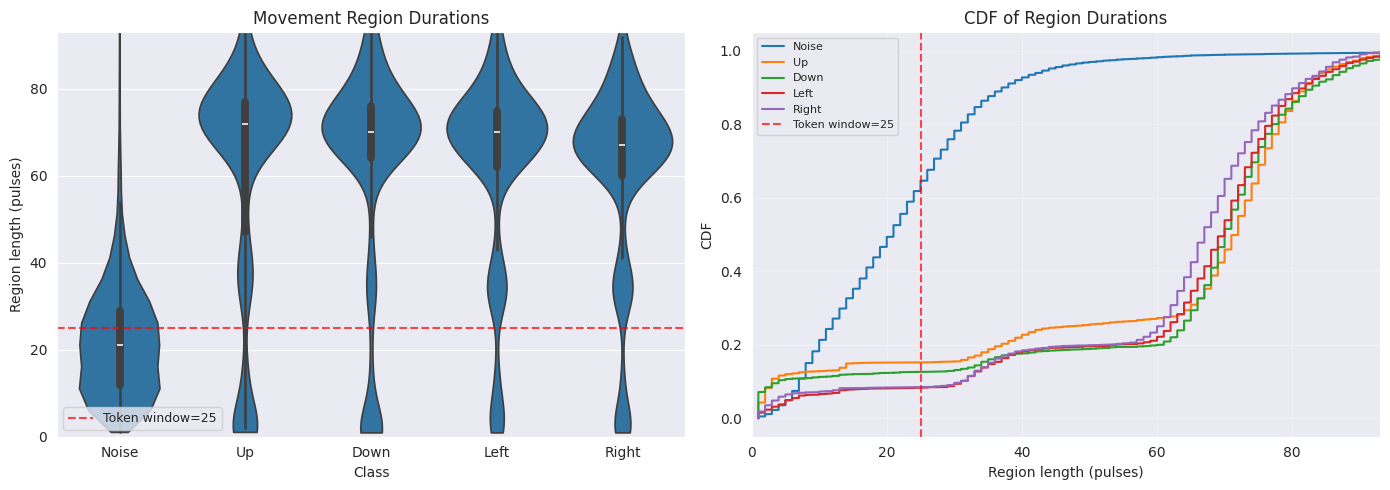


Overall: 34.3% of regions shorter than window (25), 2.3% are single-pulse spikes


In [10]:
# ---------- Plots ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Violin plot of region durations per class
order = [CLASS_NAMES[c] for c in range(NUM_CLASSES)]
sns.violinplot(data=df_regions, x='class_name', y='length_pulses', order=order,
               cut=0, inner='box', ax=axes[0])
axes[0].axhline(y=TOKEN_WINDOW, color='r', linestyle='--', alpha=0.7, label=f'Token window={TOKEN_WINDOW}')
axes[0].set_ylabel('Region length (pulses)')
axes[0].set_xlabel('Class')
axes[0].set_title('Movement Region Durations')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, min(500, df_regions['length_pulses'].quantile(0.99)))

# (b) CDF of region durations with window reference
for cls in range(NUM_CLASSES):
    subset = df_regions[df_regions['class'] == cls]['length_pulses'].values
    sorted_vals = np.sort(subset)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    axes[1].plot(sorted_vals, cdf, label=CLASS_NAMES[cls])

axes[1].axvline(x=TOKEN_WINDOW, color='r', linestyle='--', alpha=0.7, label=f'Token window={TOKEN_WINDOW}')
axes[1].set_xlabel('Region length (pulses)')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF of Region Durations')
axes[1].set_xlim(0, min(500, df_regions['length_pulses'].quantile(0.99)))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Key takeaway ----------
overall_short = (df_regions['length_pulses'] < TOKEN_WINDOW).mean() * 100
overall_spike = (df_regions['length_pulses'] == 1).mean() * 100
print(f"\nOverall: {overall_short:.1f}% of regions shorter than window ({TOKEN_WINDOW}), {overall_spike:.1f}% are single-pulse spikes")

## 5. Transition Matrix & Noise-to-Movement Ratio

Class-to-class transition counts across all experiments.

**Why this matters:**
- Reveals labeling pipeline structure: does Noise always separate movements, or do direct movement→movement transitions occur?
- Noise duty cycle explains why P3 has 31% Noise — is it longer pauses or more frequent pauses?
- Movement bout rate (transitions/sec) characterizes task tempo

In [11]:
# ---------- Transition matrix ----------
def compute_transition_matrix(labels, n_classes):
    """Count class-to-class transitions. Returns [n_classes, n_classes] count matrix."""
    T = np.zeros((n_classes, n_classes), dtype=np.int64)
    for i in range(len(labels) - 1):
        T[int(labels[i]), int(labels[i + 1])] += 1
    return T

# Global transition matrix
T_global = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
T_per_participant = {p: np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64) for p in range(4)}

for key, labels in all_labels.items():
    p, s, e = key
    T = compute_transition_matrix(labels, NUM_CLASSES)
    T_global += T
    T_per_participant[p] += T

# Row-normalize (probability of transitioning FROM row class TO column class)
def row_normalize(T):
    row_sums = T.sum(axis=1, keepdims=True)
    return np.where(row_sums > 0, T / row_sums, 0)

T_global_norm = row_normalize(T_global)

print("Global Transition Matrix (row-normalized, FROM row → TO col):")
class_labels = [CLASS_NAMES[c] for c in range(NUM_CLASSES)]
df_T = pd.DataFrame(T_global_norm, index=class_labels, columns=class_labels).round(4)
print(df_T)

# Off-diagonal transitions (exclude self-transitions)
total_transitions = T_global.sum()
self_transitions = np.trace(T_global)
off_diag = total_transitions - self_transitions
print(f"\nTotal transitions: {total_transitions:,}")
print(f"Self-transitions: {self_transitions:,} ({100*self_transitions/total_transitions:.1f}%)")
print(f"Class changes: {off_diag:,} ({100*off_diag/total_transitions:.1f}%)")

# ---------- Noise duty cycle ----------
noise_duty_rows = []
for key, labels in all_labels.items():
    p, s, e = key
    n_total = len(labels)
    n_noise = np.sum(labels == 0)
    noise_duty_rows.append({
        'participant': p, 'session': s, 'experiment': e,
        'placement': PLACEMENT_MAP[s],
        'noise_duty_pct': 100 * n_noise / n_total,
        'n_noise_regions': sum(1 for cls, _ in get_region_lengths(labels) if cls == 0),
        'n_total': n_total,
    })

df_noise = pd.DataFrame(noise_duty_rows)

# Mean noise region length per participant
noise_regions_only = df_regions[df_regions['class'] == 0]
noise_len_summary = noise_regions_only.groupby('participant')['length_pulses'].agg(
    mean_len='mean', median_len='median', count='count',
).round(1)
noise_len_summary.index = [f'P{p}' for p in noise_len_summary.index]

print("\nNoise Region Length per Participant:")
print(noise_len_summary)

# Noise duty per participant × placement
noise_pivot = df_noise.groupby(['participant', 'placement'])['noise_duty_pct'].mean().unstack()
noise_pivot = noise_pivot[['table', 'leg', 'side']]
noise_pivot.index = [f'P{p}' for p in noise_pivot.index]
print("\nNoise Duty Cycle (%) by Participant × Placement:")
print(noise_pivot.round(1))

Global Transition Matrix (row-normalized, FROM row → TO col):
        Noise      Up    Down    Left   Right
Noise  0.9555  0.0117  0.0107  0.0110  0.0110
Up     0.0143  0.9836  0.0000  0.0010  0.0012
Down   0.0135  0.0000  0.9841  0.0011  0.0013
Left   0.0127  0.0019  0.0011  0.9842  0.0000
Right  0.0129  0.0019  0.0015  0.0000  0.9838

Total transitions: 745,571
Self-transitions: 728,633 (97.7%)
Class changes: 16,938 (2.3%)

Noise Region Length per Participant:
    mean_len  median_len  count
P0      15.2        12.0   1986
P1      21.7        21.0   2043
P2      21.0        19.0   1931
P3      32.8        30.0   1803

Noise Duty Cycle (%) by Participant × Placement:
placement  table   leg  side
P0          21.8  15.5  11.7
P1          22.2  26.8  23.1
P2          28.9  22.4  13.2
P3          37.9  29.9  26.1


/tmp/ipykernel_104750/1692272037.py:25: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


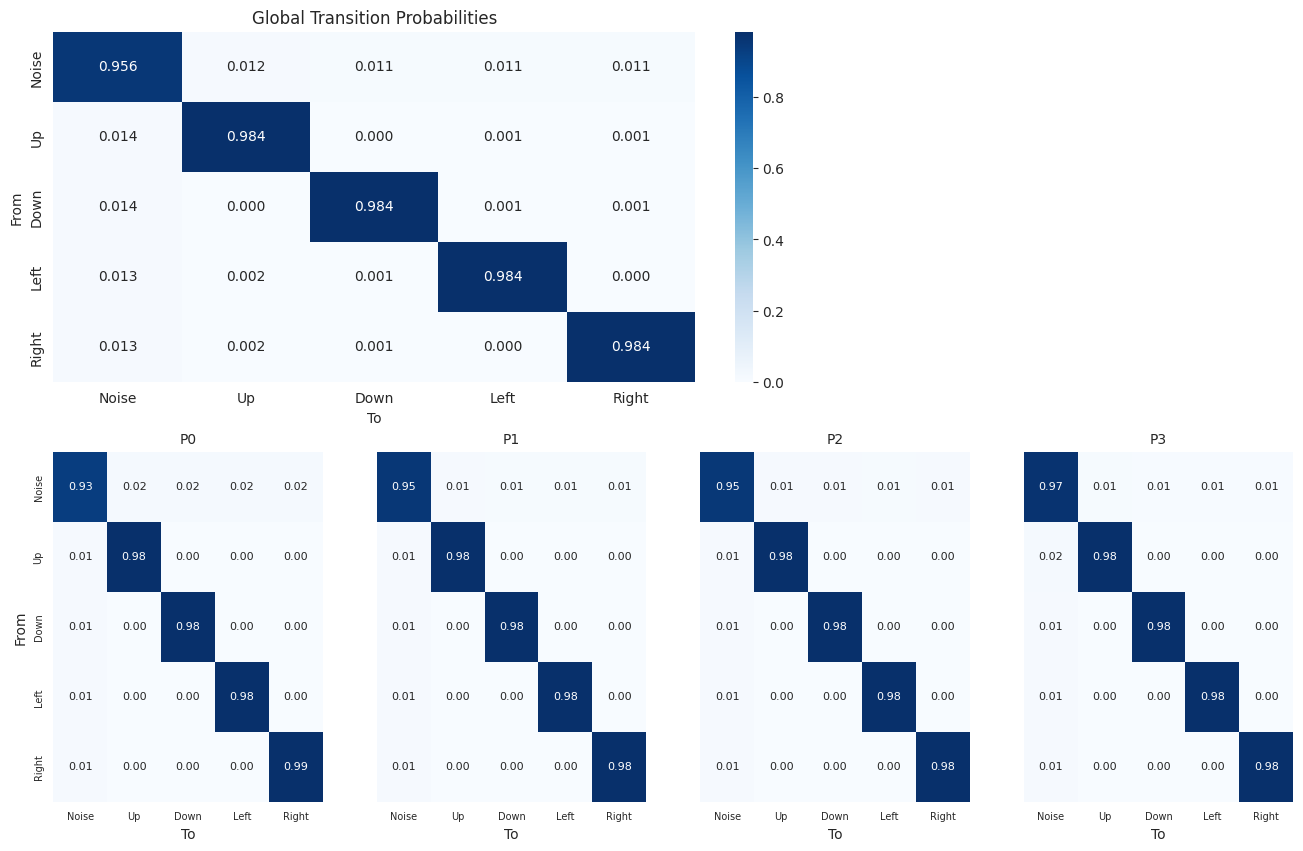

/tmp/ipykernel_104750/1692272037.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f'P{p}' for p in sorted(df_noise['participant'].unique())])


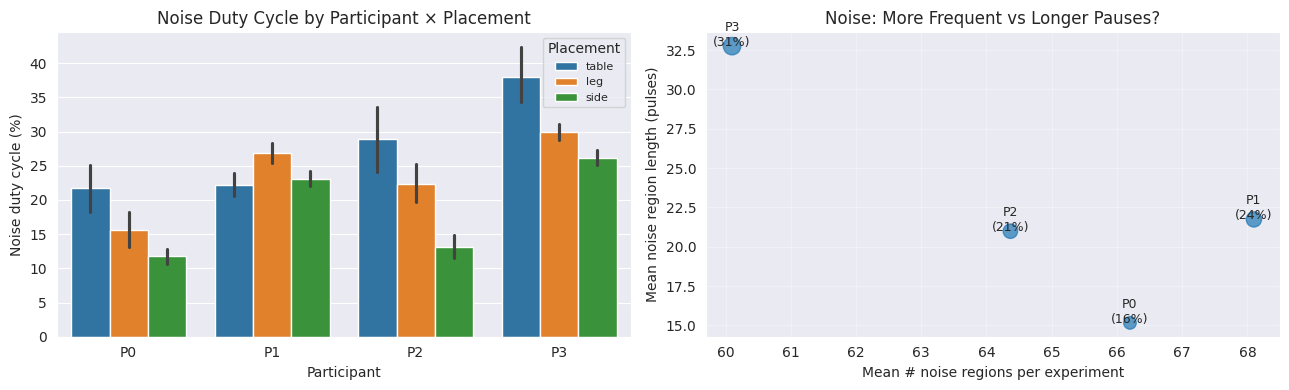

In [12]:
# ---------- Plots ----------
fig = plt.figure(figsize=(16, 10))

# (a) Global transition heatmap
ax0 = fig.add_subplot(2, 3, (1, 2))
sns.heatmap(T_global_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax0)
ax0.set_xlabel('To')
ax0.set_ylabel('From')
ax0.set_title('Global Transition Probabilities')

# (b) Per-participant transition matrices (2×2)
for idx, p in enumerate(range(4)):
    ax = fig.add_subplot(2, 4, 5 + idx)
    T_norm = row_normalize(T_per_participant[p])
    sns.heatmap(T_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels if idx == 0 else False,
                ax=ax, annot_kws={'size': 8})
    ax.set_title(f'P{p}', fontsize=10)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.set_ylabel('From')
    ax.set_xlabel('To')

plt.tight_layout()
plt.show()

# (c) Noise duty cycle bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=df_noise, x='participant', y='noise_duty_pct', hue='placement',
            hue_order=['table', 'leg', 'side'], ax=axes[0])
axes[0].set_xticklabels([f'P{p}' for p in sorted(df_noise['participant'].unique())])
axes[0].set_ylabel('Noise duty cycle (%)')
axes[0].set_xlabel('Participant')
axes[0].set_title('Noise Duty Cycle by Participant × Placement')
axes[0].legend(title='Placement', fontsize=8)

# Noise region count vs mean length (explains high duty: more regions or longer regions?)
noise_per_part = df_noise.groupby('participant').agg(
    mean_duty=('noise_duty_pct', 'mean'),
    mean_n_regions=('n_noise_regions', 'mean'),
).reset_index()
noise_per_part['mean_noise_len'] = noise_regions_only.groupby('participant')['length_pulses'].mean().values

axes[1].scatter(noise_per_part['mean_n_regions'], noise_per_part['mean_noise_len'],
                s=noise_per_part['mean_duty'] * 5, alpha=0.7)
for _, row in noise_per_part.iterrows():
    axes[1].annotate(f'P{int(row["participant"])}\n({row["mean_duty"]:.0f}%)',
                     (row['mean_n_regions'], row['mean_noise_len']),
                     ha='center', fontsize=9)
axes[1].set_xlabel('Mean # noise regions per experiment')
axes[1].set_ylabel('Mean noise region length (pulses)')
axes[1].set_title('Noise: More Frequent vs Longer Pauses?')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Joystick Kinematics per Class

Position and velocity distributions conditioned on label class.

**Why this matters:**
- Validates labeling correctness: Up → positive Y-velocity, Left → negative X-velocity, etc.
- Quantifies class separability in joystick space (baseline for Fisher ratio in preprocessing analysis)
- Noise class should cluster near zero velocity — if not, thresholds may need adjustment

In [13]:
# ---------- Collect per-sample kinematics with labels ----------
# Subsample to keep memory manageable (~50k samples)
np.random.seed(42)
MAX_SAMPLES = 50_000

kin_rows = []
for key in all_labels:
    labels = all_labels[key]
    x_f, y_f, x_v, y_v = all_kinematics[key]
    n = len(labels)
    for i in range(n):
        kin_rows.append({
            'class': int(labels[i]),
            'x_pos': x_f[i], 'y_pos': y_f[i],
            'x_vel': x_v[i], 'y_vel': y_v[i],
        })

df_kin = pd.DataFrame(kin_rows)
df_kin['class_name'] = df_kin['class'].map(CLASS_NAMES)
df_kin['vel_magnitude'] = np.sqrt(df_kin['x_vel']**2 + df_kin['y_vel']**2)

# Subsample for plotting
if len(df_kin) > MAX_SAMPLES:
    df_kin_plot = df_kin.sample(n=MAX_SAMPLES, random_state=42)
else:
    df_kin_plot = df_kin

# ---------- Per-class summary ----------
kin_summary = df_kin.groupby('class_name').agg(
    x_vel_mean=('x_vel', 'mean'), x_vel_std=('x_vel', 'std'),
    y_vel_mean=('y_vel', 'mean'), y_vel_std=('y_vel', 'std'),
    vel_mag_mean=('vel_magnitude', 'mean'), vel_mag_std=('vel_magnitude', 'std'),
    x_pos_mean=('x_pos', 'mean'), y_pos_mean=('y_pos', 'mean'),
    count=('class', 'count'),
).round(4)

print("Per-Class Kinematics Summary:")
print(kin_summary[['count', 'x_vel_mean', 'x_vel_std', 'y_vel_mean', 'y_vel_std',
                    'vel_mag_mean']].to_string())

# ---------- Pairwise Mahalanobis distance in velocity space ----------
from scipy.spatial.distance import mahalanobis

class_vel_stats = {}
for cls in range(NUM_CLASSES):
    subset = df_kin[df_kin['class'] == cls][['x_vel', 'y_vel']].values
    class_vel_stats[cls] = {'mean': subset.mean(axis=0), 'cov': np.cov(subset.T)}

print("\nPairwise Mahalanobis Distance (velocity space):")
mah_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i == j:
            continue
        pooled_cov = (class_vel_stats[i]['cov'] + class_vel_stats[j]['cov']) / 2
        try:
            d = mahalanobis(class_vel_stats[i]['mean'], class_vel_stats[j]['mean'],
                            np.linalg.inv(pooled_cov))
        except np.linalg.LinAlgError:
            d = np.nan
        mah_matrix[i, j] = d

df_mah = pd.DataFrame(mah_matrix, index=class_labels, columns=class_labels).round(2)
print(df_mah)

Per-Class Kinematics Summary:
             count  x_vel_mean  x_vel_std  y_vel_mean  y_vel_std  vel_mag_mean
class_name                                                                    
Down        139313      0.0091     0.1907      0.0183     2.4551        2.2215
Left        138988      0.0109     2.3744     -0.0046     0.2309        2.1408
Noise       174097      0.0044     0.2989      0.0029     0.3900        0.2324
Right       138843     -0.0159     2.4424      0.0118     0.2370        2.2056
Up          154450     -0.0080     0.2253     -0.0312     2.4173        2.1845

Pairwise Mahalanobis Distance (velocity space):
       Noise    Up  Down  Left  Right
Noise   0.00  0.05  0.02  0.02   0.03
Up      0.05  0.00  0.08  0.02   0.03
Down    0.02  0.08  0.00  0.01   0.01
Left    0.02  0.02  0.01  0.00   0.07
Right   0.03  0.03  0.01  0.07   0.00


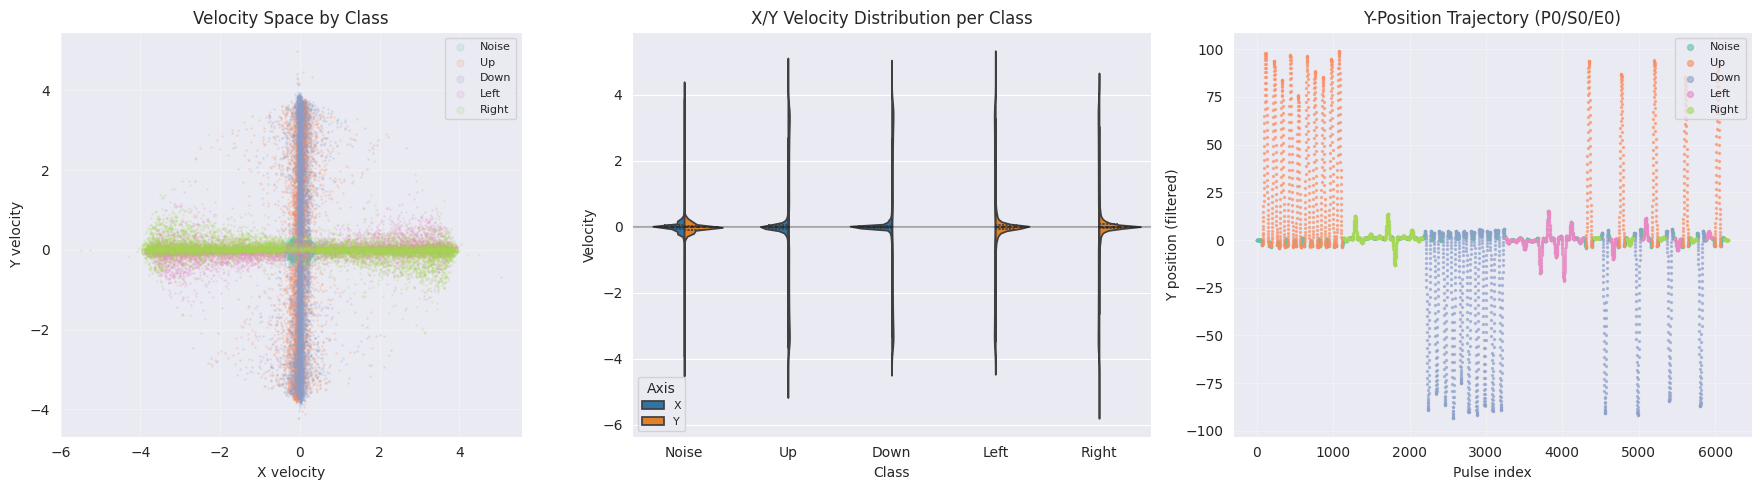

Noise velocity magnitude:    mean=0.2324, median=0.1616, 95th=0.4574
Movement velocity magnitude: mean=2.1880, median=2.3011, 5th=0.4537
Overlap between noise 95th and movement 5th percentile: YES — some ambiguity


In [14]:
# ---------- Plots ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('Set2', NUM_CLASSES)
order = [CLASS_NAMES[c] for c in range(NUM_CLASSES)]

# (a) 2D scatter: X-vel vs Y-vel, colored by class
for cls in range(NUM_CLASSES):
    subset = df_kin_plot[df_kin_plot['class'] == cls]
    axes[0].scatter(subset['x_vel'], subset['y_vel'], s=1, alpha=0.15,
                    color=colors[cls], label=CLASS_NAMES[cls])
axes[0].set_xlabel('X velocity')
axes[0].set_ylabel('Y velocity')
axes[0].set_title('Velocity Space by Class')
axes[0].legend(markerscale=5, fontsize=8)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# (b) Violin: X and Y velocity per class (side by side)
df_vel_melt = df_kin.melt(id_vars=['class_name'], value_vars=['x_vel', 'y_vel'],
                           var_name='axis', value_name='velocity')
df_vel_melt['axis'] = df_vel_melt['axis'].map({'x_vel': 'X', 'y_vel': 'Y'})

sns.violinplot(data=df_vel_melt, x='class_name', y='velocity', hue='axis',
               split=True, order=order, inner='quartile', ax=axes[1], cut=0)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Velocity')
axes[1].set_title('X/Y Velocity Distribution per Class')
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].legend(title='Axis', fontsize=8)

# (c) Example trajectory from 1 experiment, colored by label
example_key = (0, 0, 0)  # P0, S0, E0
x_f, y_f, _, _ = all_kinematics[example_key]
ex_labels = all_labels[example_key]
t = np.arange(len(ex_labels))

for cls in range(NUM_CLASSES):
    mask = ex_labels == cls
    axes[2].scatter(t[mask], y_f[mask], s=2, color=colors[cls], label=CLASS_NAMES[cls], alpha=0.6)
axes[2].set_xlabel('Pulse index')
axes[2].set_ylabel('Y position (filtered)')
axes[2].set_title(f'Y-Position Trajectory (P0/S0/E0)')
axes[2].legend(markerscale=3, fontsize=8, loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Noise velocity magnitude check ----------
noise_vel = df_kin[df_kin['class'] == 0]['vel_magnitude']
movement_vel = df_kin[df_kin['class'] != 0]['vel_magnitude']
print(f"Noise velocity magnitude:    mean={noise_vel.mean():.4f}, median={noise_vel.median():.4f}, 95th={noise_vel.quantile(0.95):.4f}")
print(f"Movement velocity magnitude: mean={movement_vel.mean():.4f}, median={movement_vel.median():.4f}, 5th={movement_vel.quantile(0.05):.4f}")
overlap = (noise_vel.quantile(0.95) > movement_vel.quantile(0.05))
print(f"Overlap between noise 95th and movement 5th percentile: {'YES — some ambiguity' if overlap else 'NO — clean separation'}")